# ESM-DMS real-data analysis (local)

Local variant of `real_data_esm_analysis.ipynb`. Runs the full workflow for the `TpoR` dataset using `esm2_t6_8M_UR50D` (6 transformer layers + embedding = 7 total).

Differences from the cluster notebook:
- Single dataset (`TpoR`) and smallest ESM2 model (`esm2_t6_8M_UR50D`).
- Embedding and inference run locally via `embed_all_sequences()` and `run_feature_inference()` — no Slurm jobs.
- `local_or_disk="both"` caches `mean_pool` and mutation-site `per_residue` embeddings to disk; inference uses `mutation_pooled`, derived from the `per_residue` cache.

In [1]:
from pathlib import Path

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from esmDMS import CellularDMSInput, ESMDMSConfig, esmDMS

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "esmDMS.py").exists():
    for parent in Path.cwd().parents:
        if (parent / "esmDMS.py").exists():
            REPO_ROOT = parent
            break

DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "raw_data"
ANALYSIS_DIR = DATA_DIR / "esm_data_analysis"
SEQUENCE_DIR = ANALYSIS_DIR / "sequence_data"
FIGURE_DIR = ANALYSIS_DIR / "figures"
TABLE_DIR = ANALYSIS_DIR / "tables"

SEQUENCE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="darkgrid")
REPO_ROOT

/net/dali/home/barton/dhw28/popDMS/esmDMS/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS')

## Dataset Registry

Single cellular dataset (`TpoR`) using a MaveDB nucleotide-count file.

In [3]:
DATASETS = {
    "TpoR": CellularDMSInput(
        reference_nuc_path=RAW_DIR / "TpoR_reference_sequence.dat",
        mavedb_csv_path=RAW_DIR / "TpoR_nucleotide_counts.csv",
    ),
}

pd.DataFrame(
    {"dataset": dataset, "kind": "cellular", "save_dir": str(SEQUENCE_DIR / dataset)}
    for dataset in DATASETS
)

,dataset,kind,save_dir
0,TpoR,cellular,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


## Controls

`esm2_t6_8M_UR50D` has 6 transformer layers plus the initial embedding layer, giving 7 total hidden states (indices 0–6).

In [4]:
# TODO(esmDMS.py): add a public available_layers() method so notebooks do not hard-code model layers.
LAYERS = list(range(7))
REPRESENTATIVE_LAYER = 6

RAW_EMBEDDING_TYPES = ("mutation_pooled", "mean_pool", "per_residue")
EMBEDDING_TYPE = "mutation_pooled"
RAW_CACHE_TYPES = ("mean_pool", "per_residue")

ABSTRACTION_METHOD = "Embeddings"
ABSTRACTION_PARAMS = {"norm_scheme": "none"}
NORM_SCHEME = ABSTRACTION_PARAMS["norm_scheme"]


## Create esmDMS Runner

Each dataset gets its own `esmDMS` object with a dataset-specific save directory.

In [5]:
runners = {}

for dataset, input_data in DATASETS.items():
    config = ESMDMSConfig(
        embedding_model="esm2_t6_8M_UR50D",
        embedding_method=EMBEDDING_TYPE,
        local_or_disk="both",
        save_dir=str(SEQUENCE_DIR / dataset / "local_t6"),
        dataset_name=dataset,
    )
    runners[dataset] = esmDMS(input_data=input_data, config=config)

runners

{'TpoR': <esmDMS.esmDMS at 0x7f8df7e16260>}

## Process Raw Data

Raw input parsing is handled by `esmDMS.process_raw_data()`.

In [6]:
processing_rows = []

for dataset, runner in runners.items():
    runner.process_raw_data(drop_stop_codons=True)
    df = runner.sequence_dataframe
    processing_rows.append({
        "dataset": dataset,
        "kind": "cellular",
        "rows": len(df),
        "sequence_count": df["SequenceIndex"].nunique(),
        "replicate_count": df["Replicate"].nunique(),
        "generation_count": df["Generation"].nunique(),
    })

processing_summary = pd.DataFrame(processing_rows)
processing_summary.to_csv(TABLE_DIR / "raw_processing_summary_local.csv", index=False)
processing_summary

,dataset,kind,rows,sequence_count,replicate_count,generation_count
0,TpoR,cellular,12948,1079,6,2


## Current Class Cache Status

This checks the paths that the current `esmDMS` class will use.

In [7]:
# TODO(esmDMS.py): add a public cache_status(layers, abstraction_method, norm_scheme) method.
cache_rows = []

for dataset, runner in runners.items():
    for layer in LAYERS:
        row = {
            "dataset": dataset,
            "layer": layer,
            "mean_pool_path": str(runner._embedding_path(layer, "mean_pool")),
            "mean_pool_exists": runner._embedding_path(layer, "mean_pool").exists(),
            "per_residue_path": str(runner._embedding_path(layer, "per_residue")),
            "per_residue_exists": runner._embedding_path(layer, "per_residue").exists(),
        }
        for embedding_type in RAW_EMBEDDING_TYPES:
            path = runner._inference_path(ABSTRACTION_METHOD, layer, NORM_SCHEME, embedding_type)
            row[f"{embedding_type}_inference_path"] = str(path)
            row[f"{embedding_type}_inference_exists"] = path.exists()
        cache_rows.append(row)

cache_status = pd.DataFrame(cache_rows)
cache_status.to_csv(TABLE_DIR / "current_class_cache_status_local.csv", index=False)
cache_status


,dataset,layer,mean_pool_path,mean_pool_exists,per_residue_path,per_residue_exists,mutation_pooled_inference_path,mutation_pooled_inference_exists,mean_pool_inference_path,mean_pool_inference_exists,per_residue_inference_path,per_residue_inference_exists
0,TpoR,0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False
1,TpoR,1,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False
2,TpoR,2,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False
3,TpoR,3,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False
4,TpoR,4,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False
5,TpoR,5,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False
6,TpoR,6,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False


## Embed Sequences

Runs embedding locally via `embed_all_sequences()`. This replaces the Slurm embedding batch jobs and merge step from the cluster notebook. With `local_or_disk="both"`, mutation-site `per_residue` and `mean_pool` caches are written to disk. This cell skips embedding when both cache types already exist for every layer.

> **Note:** `create_embedding_batch_job()`, `create_embedding_batch_merge_job()`, and the merge polling loop from the cluster notebook require Slurm and cannot run locally.

In [8]:
for dataset, runner in runners.items():
    cache_complete = all(
        runner._embedding_path(layer, cache_type).exists()
        for layer in LAYERS
        for cache_type in RAW_CACHE_TYPES
    )
    if cache_complete:
        print(f"Skipping {dataset}: mean_pool and per_residue caches already exist.")
        continue

    print(f"Embedding {dataset}...")
    runner.embed_all_sequences(layer="all")
    print(f"  Done.")

Skipping TpoR: mean_pool and per_residue caches already exist.


## Run Inference

Runs inference locally via `run_feature_inference()` for each layer. This replaces `create_inference_job()` and the Slurm inference array from the cluster notebook. `mutation_pooled` is derived from the saved mutation-site `per_residue` embeddings; raw `per_residue` inference treats each mutation-site residue embedding as its own residue-level population member.

> **Note:** `create_inference_job()` and `run_inference_job()` from the cluster notebook require Slurm and cannot run locally.

In [9]:
for dataset, runner in runners.items():
    for embedding_type in RAW_EMBEDDING_TYPES:
        for layer in LAYERS:
            runner.run_feature_inference(
                layer=layer,
                abstraction_method=ABSTRACTION_METHOD,
                abstraction_params=ABSTRACTION_PARAMS,
                embedding_type=embedding_type,
            )


Loading inference results from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_none_Layer_0_none_inference_results.pkl
Loading inference results from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_none_Layer_1_none_inference_results.pkl
Loading inference results from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_none_Layer_2_none_inference_results.pkl
Loading inference results from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_none_Layer_3_none_inference_results.pkl
Loading inference results from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_none_Layer_4_none_inference_re

## Load Completed Inference Results

Results are already cached in memory from the cell above. This cell re-loads them from disk to confirm the disk cache is consistent.

In [10]:
inference_results = {}

for dataset, runner in runners.items():
    inference_results[dataset] = {}
    for embedding_type in RAW_EMBEDDING_TYPES:
        inference_results[dataset][embedding_type] = {}
        for layer in LAYERS:
            inference_results[dataset][embedding_type][layer] = runner.load_inference_results(
                layer=layer,
                abstraction_method=ABSTRACTION_METHOD,
                norm_scheme=NORM_SCHEME,
                embedding_type=embedding_type,
            )


In [12]:
layer_results.keys()

dict_keys(['mutation_pooled', 'mean_pool', 'per_residue'])

In [ ]:
layer_results['per_residue']

## Inference Summary

Run this after completed inference results have been loaded from the class inference cache.

In [11]:
# TODO(esmDMS.py): add an inference_summary() method that returns this table from stored results.
inference_rows = []

for dataset, layer_results in inference_results.items():
    for layer, result in layer_results.items():
        inference_rows.append({
            "dataset": dataset,
            "kind": "cellular",
            "layer": layer,
            "n_replicates": result.s.shape[0],
            "n_dimensions": result.s.shape[1],
            "gamma_opt": result.gamma_opt,
            "s_joint_mean": result.s_joint.mean(),
            "s_joint_std": result.s_joint.std(),
        })

inference_summary = pd.DataFrame(inference_rows)
inference_summary.to_csv(TABLE_DIR / "inference_result_summary_local.csv", index=False)
inference_summary

AttributeError: 'dict' object has no attribute 's'

## Replicate Consistency By Layer

Layer-wise replicate consistency plots are delegated to `esmDMS.plot_avg_rep_correlations_by_layer()`.

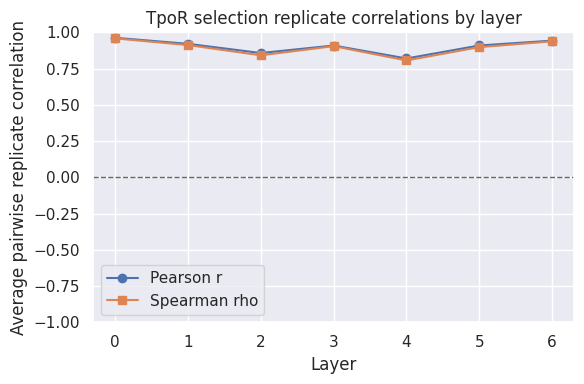

No abstraction method specified. Using raw embeddings as features.
Loading per_residue embeddings from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_per_residue_none_Layer_0_seq_to_features.pkl
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
No abstraction method specified. Using raw embeddings as features.
Loading per_residue embeddings from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_per_residue_none_Layer_1_seq_to_features.pkl
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
No abstraction method specified. Using raw embeddings as features.
Loading per_residue embeddings from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_per_residue_none_Layer_2_seq_to_features.pkl
Inference plotting: dropping 1 sequence(s) with no mutation-s

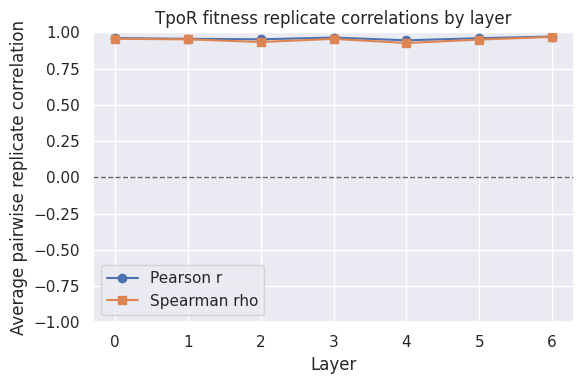

In [ ]:
for dataset, runner in runners.items():
    for embedding_type in RAW_EMBEDDING_TYPES:
        fig, _ = runner.plot_avg_rep_correlations_by_layer(
            layers=LAYERS,
            abstraction_method=ABSTRACTION_METHOD,
            norm_scheme=NORM_SCHEME,
            embedding_type=embedding_type,
            comparison="selection",
            label=f"{dataset} {embedding_type}",
        )
        display(fig)
        plt.close(fig)

        fig, _ = runner.plot_avg_rep_correlations_by_layer(
            layers=LAYERS,
            abstraction_method=ABSTRACTION_METHOD,
            norm_scheme=NORM_SCHEME,
            embedding_type=embedding_type,
            comparison="fitness",
            label=f"{dataset} {embedding_type}",
        )
        display(fig)
        plt.close(fig)


## Representative Replicate Scatter Plots

Replicate scatter plots are delegated to `esmDMS.plot_rep_sel_comps()` and `esmDMS.plot_rep_fit_comps()`.

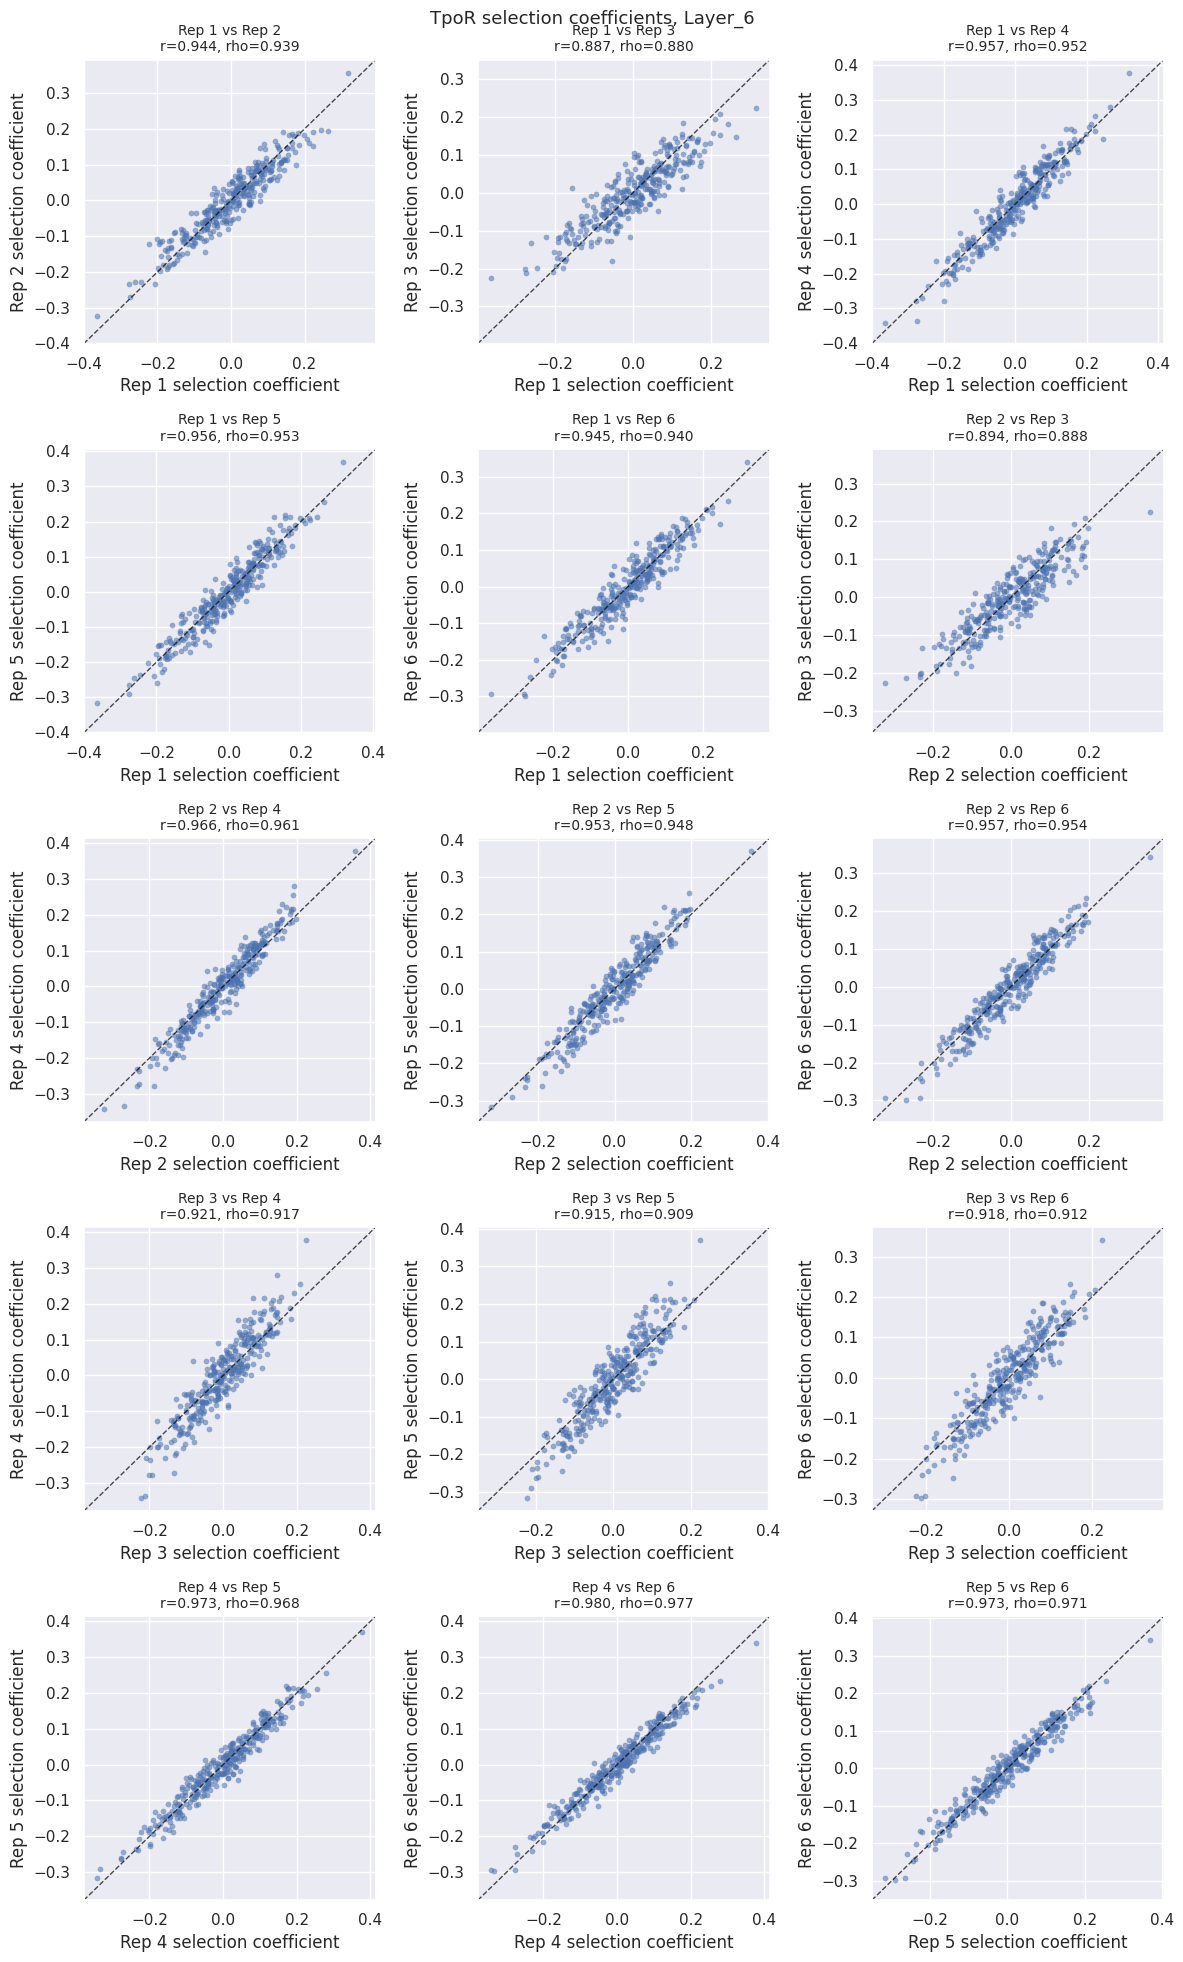

No abstraction method specified. Using raw embeddings as features.
Embeddings already exist in memory. Returning existing embeddings.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.


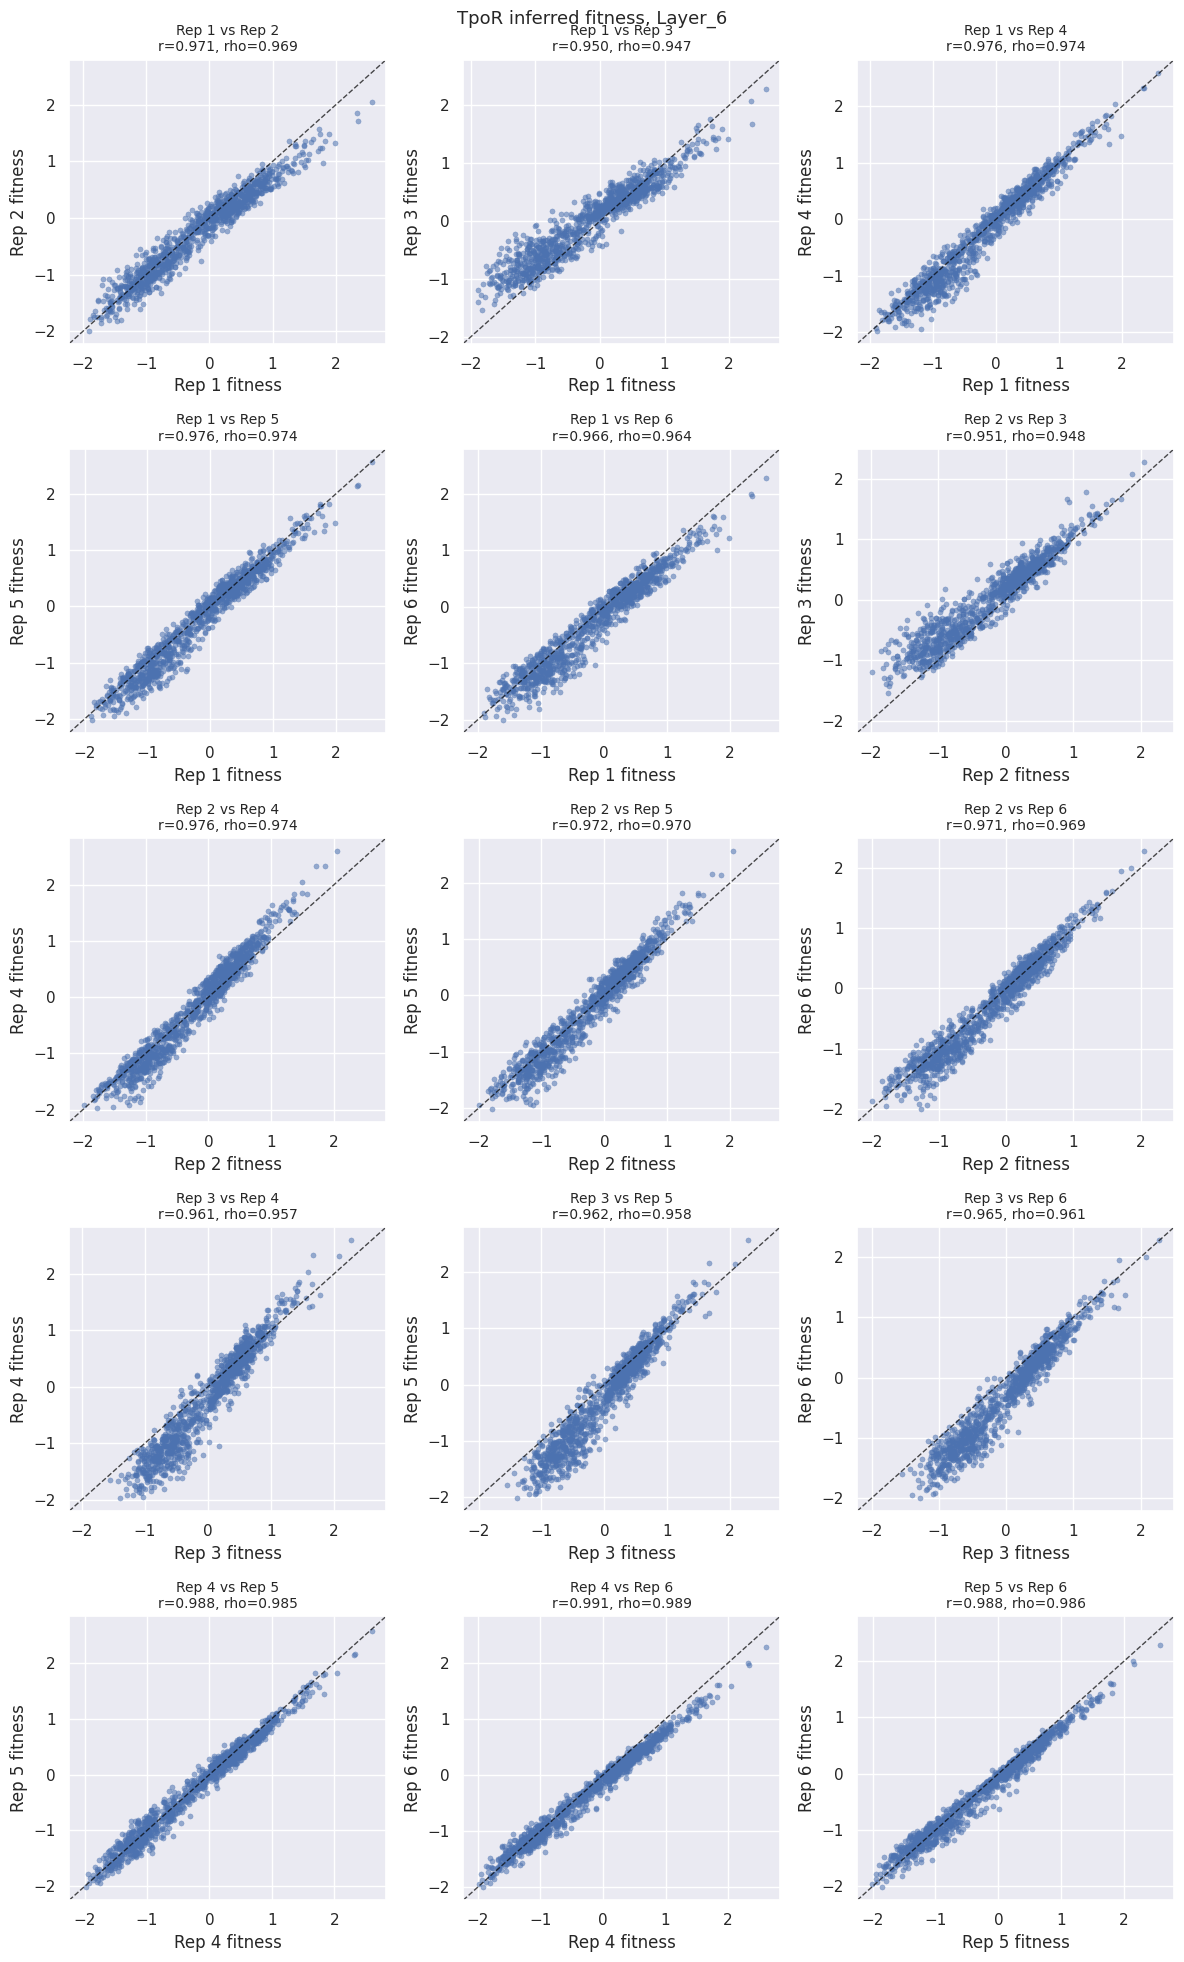

In [ ]:
for dataset, runner in runners.items():
    for embedding_type in RAW_EMBEDDING_TYPES:
        fig = runner.plot_rep_sel_comps(
            layer=REPRESENTATIVE_LAYER,
            abstraction_method=ABSTRACTION_METHOD,
            norm_scheme=NORM_SCHEME,
            embedding_type=embedding_type,
            label=f"{dataset} {embedding_type}",
        )
        display(fig)
        plt.close(fig)

        fig = runner.plot_rep_fit_comps(
            layer=REPRESENTATIVE_LAYER,
            abstraction_method=ABSTRACTION_METHOD,
            norm_scheme=NORM_SCHEME,
            embedding_type=embedding_type,
            label=f"{dataset} {embedding_type}",
        )
        display(fig)
        plt.close(fig)


## Sparse Autoencoder Reconstruction Sweep

Train several SAE abstractions on one representative layer, visualize reconstruction quality in the notebook, and run inference for each SAE feature space. Plots are displayed only; they are not written to disk.

Training/loading SAE_nf64_sp0p0001 for TpoR, layer 6
Embeddings already exist in memory. Returning existing embeddings.
SAE_nf64_sp0p0001 abstraction: dropping 1 sequence(s) with no mutation-site features.
Abstracted already saved in /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_SAE_nf64_sp0p0001_Layer_6_seq_to_features.pkl
Loading inference results from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_SAE_nf64_sp0p0001_Layer_6_none_inference_results.pkl
Embeddings already exist in memory. Returning existing embeddings.


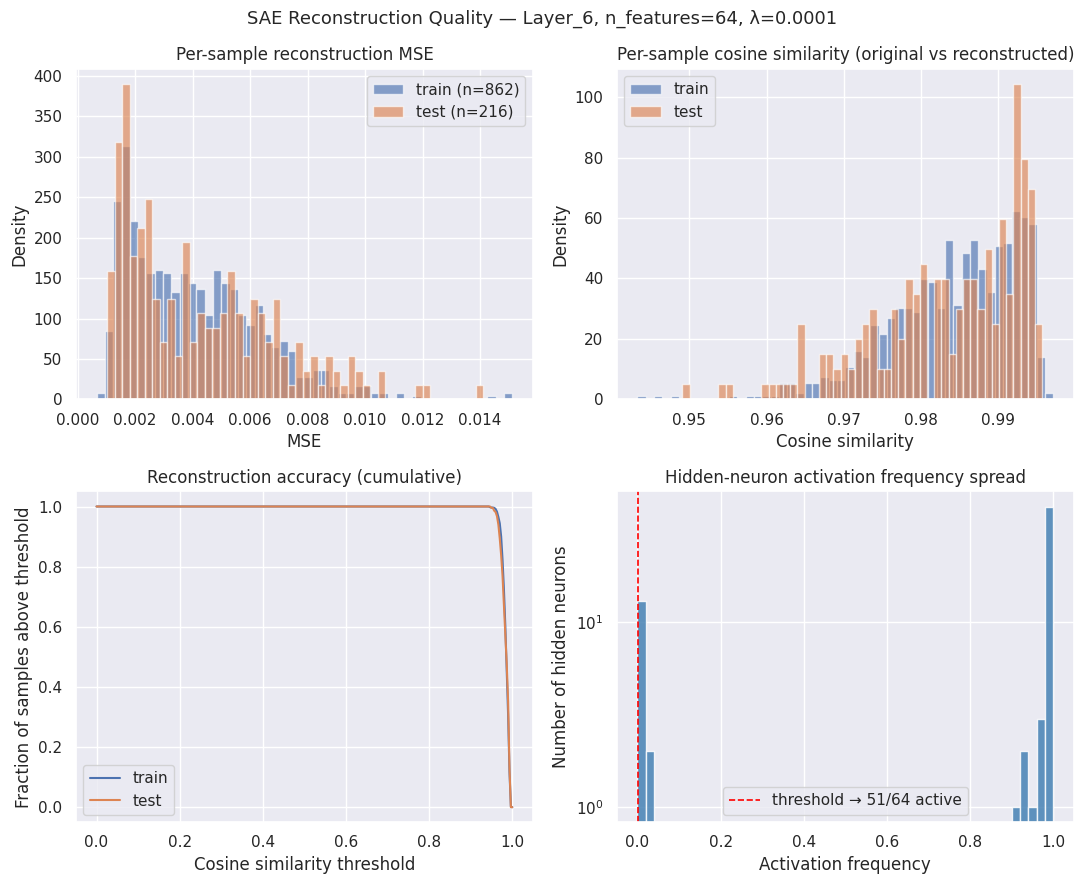

Training/loading SAE_nf128_sp0p001 for TpoR, layer 6
Embeddings already exist in memory. Returning existing embeddings.
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
Abstracted already saved in /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_SAE_nf128_sp0p001_Layer_6_seq_to_features.pkl
Loading inference results from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_SAE_nf128_sp0p001_Layer_6_none_inference_results.pkl
Embeddings already exist in memory. Returning existing embeddings.


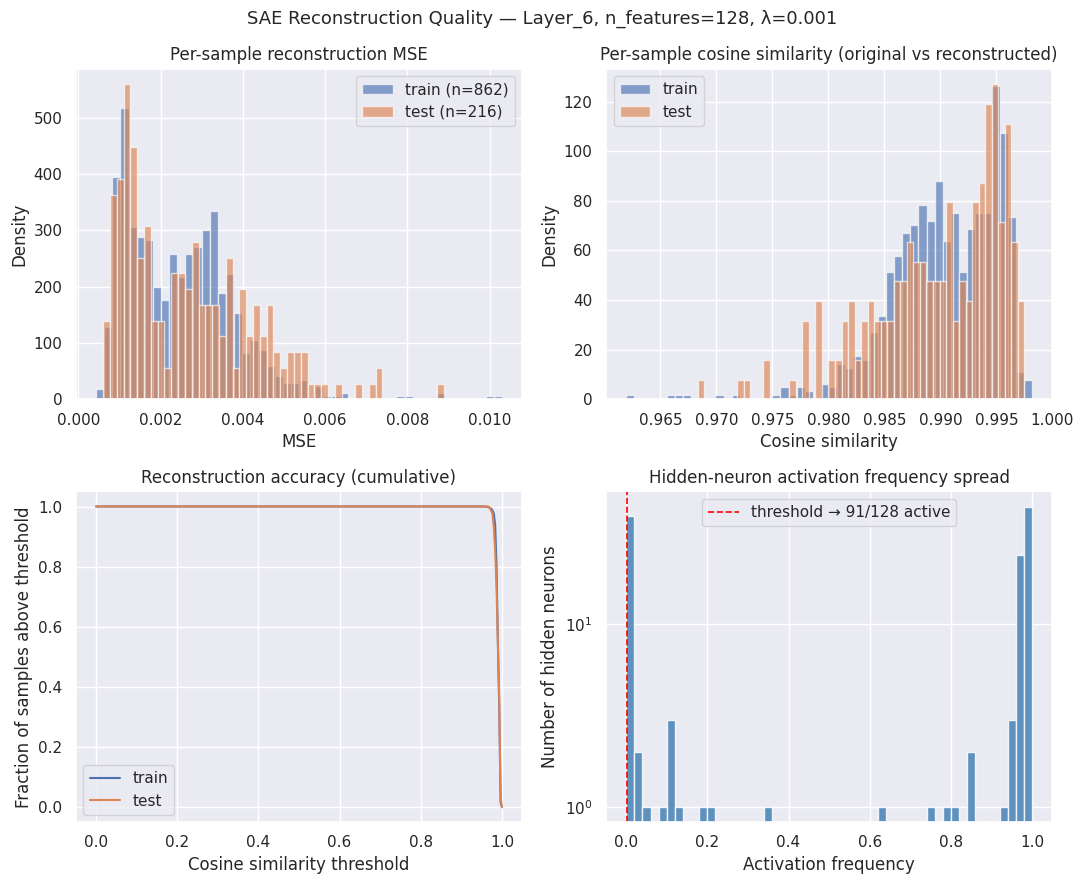

Training/loading SAE_nf256_sp0p001 for TpoR, layer 6
Embeddings already exist in memory. Returning existing embeddings.
SAE_nf256_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
Abstracted already saved in /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_SAE_nf256_sp0p001_Layer_6_seq_to_features.pkl
Loading inference results from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_SAE_nf256_sp0p001_Layer_6_none_inference_results.pkl
Embeddings already exist in memory. Returning existing embeddings.


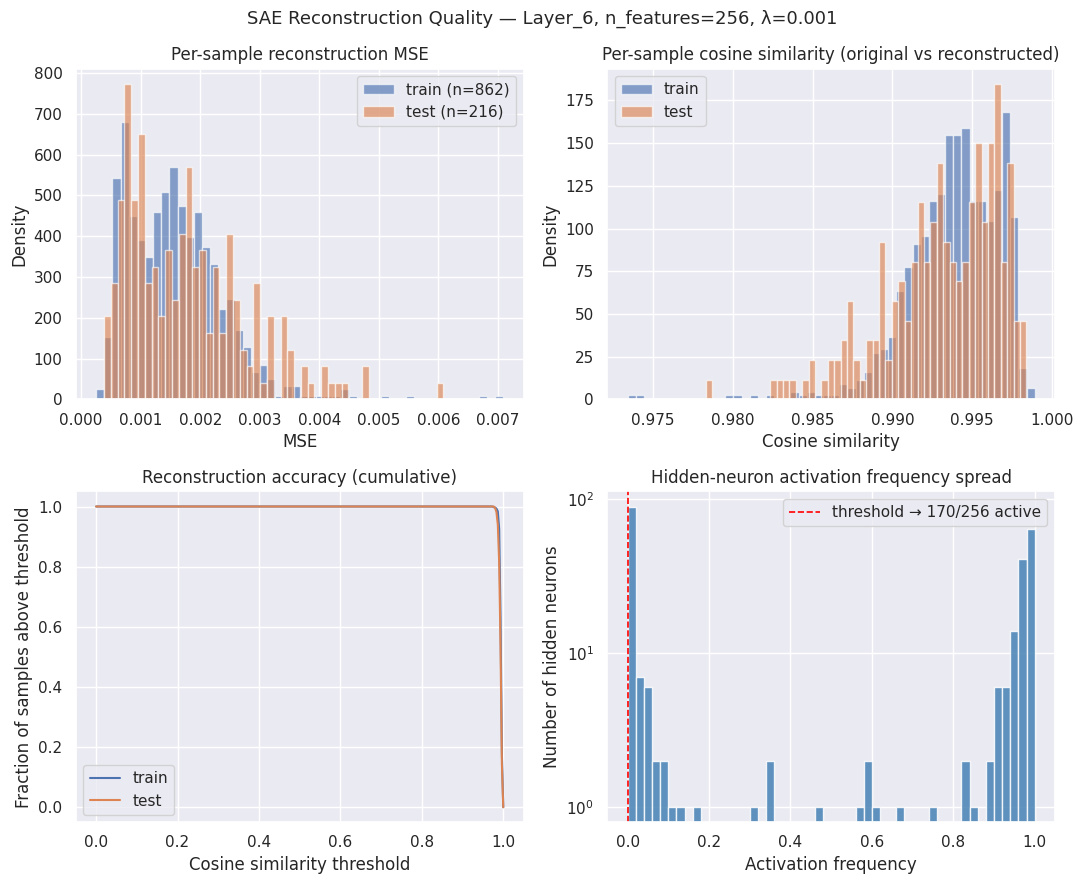

,dataset,layer,method,n_features,sparsity_coeff,epochs,batch_size
0,TpoR,6,SAE_nf64_sp0p0001,64,0.0001,50,128
1,TpoR,6,SAE_nf128_sp0p001,128,0.0010,50,128
2,TpoR,6,SAE_nf256_sp0p001,256,0.0010,50,128


In [ ]:
SAE_TEST_LAYER = REPRESENTATIVE_LAYER
SAE_PARAM_GRID = [
    {"n_features": 64, "sparsity_coeff": 1e-4, "epochs": 50, "batch_size": 128},
    {"n_features": 128, "sparsity_coeff": 1e-3, "epochs": 50, "batch_size": 128},
    {"n_features": 256, "sparsity_coeff": 1e-3, "epochs": 50, "batch_size": 128},
]


def sae_method_name(params):
    sparsity = str(params["sparsity_coeff"]).replace(".", "p").replace("-", "m")
    return f"SAE_nf{params['n_features']}_sp{sparsity}"


sae_runs = []

for dataset, runner in runners.items():
    for params in SAE_PARAM_GRID:
        method = sae_method_name(params)
        sae_params = {**params, "norm_scheme": NORM_SCHEME}
        print(f"Training/loading {method} for {dataset}, layer {SAE_TEST_LAYER}")
        runner.create_feature_space(
            layer=SAE_TEST_LAYER,
            method=method,
            method_params=sae_params,
            embedding_type=EMBEDDING_TYPE,
        )
        runner.run_feature_inference(
            layer=SAE_TEST_LAYER,
            abstraction_method=method,
            abstraction_params=sae_params,
            embedding_type=EMBEDDING_TYPE,
        )
        fig = runner.visualize_sae_reconstructions(
            layer=SAE_TEST_LAYER,
            method_params=sae_params,
            save=False,
        )
        display(fig)
        plt.close(fig)
        sae_runs.append({
            "dataset": dataset,
            "layer": SAE_TEST_LAYER,
            "method": method,
            **params,
        })

sae_run_table = pd.DataFrame(sae_runs)
sae_run_table


## SAE Fitness Comparisons

Compare inferred sequence fitness from the raw mutation-pooled embedding model against each SAE abstraction. Each scatter plot annotates the Spearman rho between methods.

No abstraction method specified. Using raw embeddings as features.
Embeddings already exist in memory. Returning existing embeddings.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Abstracted features already exist in memory. Returning existing features.


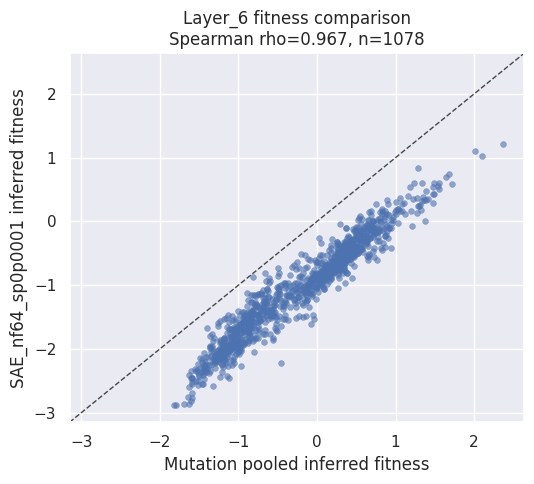

No abstraction method specified. Using raw embeddings as features.
Embeddings already exist in memory. Returning existing embeddings.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Abstracted features already exist in memory. Returning existing features.


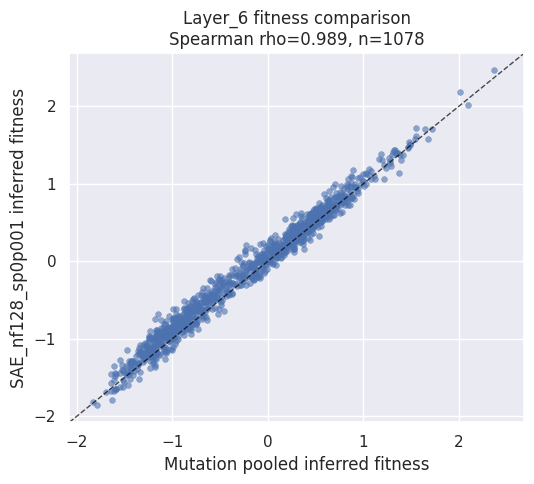

No abstraction method specified. Using raw embeddings as features.
Embeddings already exist in memory. Returning existing embeddings.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Abstracted features already exist in memory. Returning existing features.


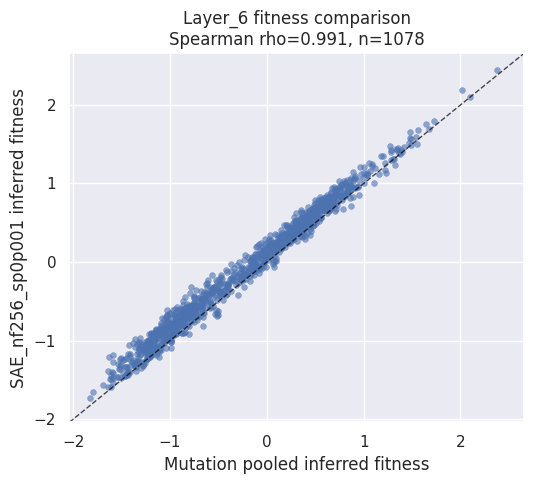

,dataset,layer,left_method,right_method,spearman_rho,n_sequences,n_features,sparsity_coeff,epochs,batch_size,norm_scheme
0,TpoR,6,none,SAE_nf64_sp0p0001,0.967318,1078,64,0.0001,50,128,none
1,TpoR,6,none,SAE_nf128_sp0p001,0.988979,1078,128,0.0010,50,128,none
2,TpoR,6,none,SAE_nf256_sp0p001,0.990859,1078,256,0.0010,50,128,none


In [ ]:
sae_comparison_rows = []

for run in sae_runs:
    runner = runners[run["dataset"]]
    sae_params = {
        "n_features": run["n_features"],
        "sparsity_coeff": run["sparsity_coeff"],
        "epochs": run["epochs"],
        "batch_size": run["batch_size"],
        "norm_scheme": NORM_SCHEME,
    }
    fig, stats = runner.plot_fitness_method_comparison(
        layer=run["layer"],
        left_abstraction_method=ABSTRACTION_METHOD,
        right_abstraction_method=run["method"],
        right_abstraction_params=sae_params,
        embedding_type=EMBEDDING_TYPE,
        norm_scheme=NORM_SCHEME,
        left_label="Mutation pooled",
        right_label=run["method"],
    )
    display(fig)
    plt.close(fig)
    sae_comparison_rows.append({"dataset": run["dataset"], **stats, **sae_params})

sae_comparison_summary = pd.DataFrame(sae_comparison_rows)
sae_comparison_summary


## SAE Fitness Correlation Across Layers

Use one SAE setting across multiple layers and plot the Spearman rho between raw mutation-pooled inferred fitness and SAE-derived inferred fitness by layer. Adjust `SAE_LAYER_SWEEP_LAYERS` or `SAE_LAYER_SWEEP_PARAMS` to control runtime.

In [ ]:
SAE_LAYER_SWEEP_LAYERS = LAYERS
SAE_LAYER_SWEEP_PARAMS = {"n_features": 128, "sparsity_coeff": 1e-3, "epochs": 50, "batch_size": 128}
SAE_LAYER_SWEEP_METHOD = sae_method_name(SAE_LAYER_SWEEP_PARAMS)
SAE_LAYER_SWEEP_METHOD


'SAE_nf128_sp0p001'

Embeddings already exist in memory. Returning existing embeddings.
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
Abstracted already saved in /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_SAE_nf128_sp0p001_Layer_0_seq_to_features.pkl
Loading inference results from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_SAE_nf128_sp0p001_Layer_0_none_inference_results.pkl
Embeddings already exist in memory. Returning existing embeddings.
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
Abstracted already saved in /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_SAE_nf128_sp0p001_Layer_1_seq_to_features.pkl
Loading inference results from /net/dali/home/barton/dhw28/popDMS/esm

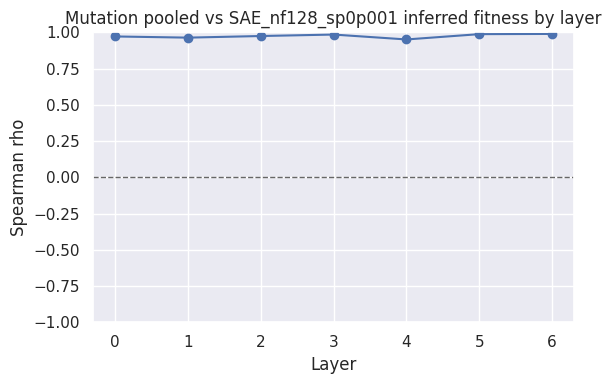

,dataset,layer,spearman_rho,n_sequences
0,TpoR,0,0.971568,1078
1,TpoR,1,0.963403,1078
2,TpoR,2,0.974591,1078
3,TpoR,3,0.984673,1078
4,TpoR,4,0.950861,1078
5,TpoR,5,0.987542,1078
6,TpoR,6,0.988979,1078


In [ ]:
layer_sweep_summaries = []

for dataset, runner in runners.items():
    sae_params = {**SAE_LAYER_SWEEP_PARAMS, "norm_scheme": NORM_SCHEME}
    for layer in SAE_LAYER_SWEEP_LAYERS:
        runner.create_feature_space(
            layer=layer,
            method=SAE_LAYER_SWEEP_METHOD,
            method_params=sae_params,
            embedding_type=EMBEDDING_TYPE,
        )
        runner.run_feature_inference(
            layer=layer,
            abstraction_method=SAE_LAYER_SWEEP_METHOD,
            abstraction_params=sae_params,
            embedding_type=EMBEDDING_TYPE,
        )

    fig, corr_df = runner.plot_fitness_method_correlation_by_layer(
        layers=SAE_LAYER_SWEEP_LAYERS,
        left_abstraction_method=ABSTRACTION_METHOD,
        right_abstraction_method=SAE_LAYER_SWEEP_METHOD,
        right_abstraction_params=sae_params,
        embedding_type=EMBEDDING_TYPE,
        norm_scheme=NORM_SCHEME,
        left_label="Mutation pooled",
        right_label=SAE_LAYER_SWEEP_METHOD,
    )
    display(fig)
    plt.close(fig)
    corr_df.insert(0, "dataset", dataset)
    layer_sweep_summaries.append(corr_df)

sae_layer_sweep_summary = pd.concat(layer_sweep_summaries, ignore_index=True)
sae_layer_sweep_summary


## Method Fitness Consistency Ranking

Compare raw embedding choices and SAE abstractions by cross-replicate inferred-fitness Spearman rho. Higher mean rho means the feature space gives more consistent inferred fitness across replicate pairs.

In [ ]:
METHOD_CONSISTENCY_SPECS = [
    {
        "label": "mutation_pooled",
        "embedding_type": "mutation_pooled",
        "abstraction_method": ABSTRACTION_METHOD,
        "abstraction_params": ABSTRACTION_PARAMS,
    },
    {
        "label": "mean_pool",
        "embedding_type": "mean_pool",
        "abstraction_method": ABSTRACTION_METHOD,
        "abstraction_params": ABSTRACTION_PARAMS,
    },
    {
        "label": "per_residue",
        "embedding_type": "per_residue",
        "abstraction_method": ABSTRACTION_METHOD,
        "abstraction_params": ABSTRACTION_PARAMS,
    },
    {
        "label": SAE_LAYER_SWEEP_METHOD,
        "embedding_type": EMBEDDING_TYPE,
        "abstraction_method": SAE_LAYER_SWEEP_METHOD,
        "abstraction_params": {**SAE_LAYER_SWEEP_PARAMS, "norm_scheme": NORM_SCHEME},
    },
]

consistency_summaries = []
consistency_details = []

for dataset, runner in runners.items():
    fig, summary_df, detail_df = runner.analyze_method_fitness_consistency_by_layer(
        layers=LAYERS,
        method_specs=METHOD_CONSISTENCY_SPECS,
        norm_scheme=NORM_SCHEME,
        ensure_inference=True,
    )
    display(fig)
    plt.close(fig)
    summary_df.insert(0, "dataset", dataset)
    detail_df.insert(0, "dataset", dataset)
    consistency_summaries.append(summary_df)
    consistency_details.append(detail_df)

method_consistency_summary = pd.concat(consistency_summaries, ignore_index=True)
method_consistency_detail = pd.concat(consistency_details, ignore_index=True)
method_consistency_summary


No saved inference results found at /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_per_residue_none_Layer_0_none_inference_results.pkl. Running inference and saving results.
No abstraction method specified. Using raw embeddings as features.
Embeddings already exist in memory. Returning existing embeddings.
Inference: dropping 1 sequence(s) with no mutation-site features.


ValueError: Inference requires one vector per sequence, but sequence 0 has feature shape (1, 320). Use embedding_type='mutation_pooled' or embedding_type='mean_pool', or add an abstraction that explicitly handles per-residue features.

In [ ]:
method_consistency_ranking = (
    method_consistency_summary
    .groupby(["dataset", "label", "embedding_type", "abstraction_method"], as_index=False)
    .agg(
        mean_layer_rho=("mean_spearman_rho", "mean"),
        median_layer_rho=("mean_spearman_rho", "median"),
        best_layer_rho=("mean_spearman_rho", "max"),
        worst_layer_rho=("mean_spearman_rho", "min"),
        n_layers=("layer", "nunique"),
    )
    .sort_values(["dataset", "mean_layer_rho"], ascending=[True, False])
)
method_consistency_ranking


,dataset,label,embedding_type,abstraction_method,mean_layer_rho,median_layer_rho,best_layer_rho,worst_layer_rho,n_layers
1,TpoR,mean_pool,mean_pool,none,0.981448,0.979325,0.994753,0.972503,7
0,TpoR,SAE_nf128_sp0p001,mutation_pooled,SAE_nf128_sp0p001,0.958636,0.958924,0.970338,0.949559,7
2,TpoR,mutation_pooled,mutation_pooled,none,0.948571,0.951722,0.968363,0.926401,7


Loading inference results from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_none_Layer_6_none_inference_results.pkl
No abstraction method specified. Using raw embeddings as features.
Embeddings already exist in memory. Returning existing embeddings.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Loading inference results from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_SAE_nf64_sp0p0001_Layer_6_none_inference_results.pkl
Abstracted features already exist in memory. Returning existing features.
Loading inference results from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/sequence_data/TpoR/local_t6/TpoR_esm2_t6_8M_UR50D_mutation_pooled_SAE_nf128_sp0p001_Layer_6_none_inference_results.pkl
Abstracted features already exist in memory. Returning existing features.
Loading inf

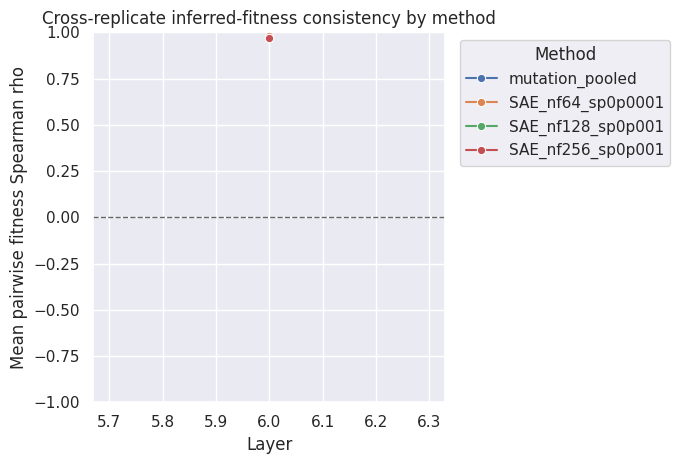

,dataset,label,layer,mean_spearman_rho,median_spearman_rho,n_pairs,n_sequences,embedding_type,abstraction_method
1,TpoR,SAE_nf64_sp0p0001,6,0.978259,0.976815,15,1078,mutation_pooled,SAE_nf64_sp0p0001
2,TpoR,SAE_nf128_sp0p001,6,0.970338,0.971106,15,1078,mutation_pooled,SAE_nf128_sp0p001
3,TpoR,SAE_nf256_sp0p001,6,0.969750,0.970167,15,1078,mutation_pooled,SAE_nf256_sp0p001
0,TpoR,mutation_pooled,6,0.968363,0.969035,15,1078,mutation_pooled,none


In [ ]:
SAE_GRID_CONSISTENCY_SPECS = [
    {
        "label": "mutation_pooled",
        "embedding_type": "mutation_pooled",
        "abstraction_method": ABSTRACTION_METHOD,
        "abstraction_params": ABSTRACTION_PARAMS,
    },
    *[
        {
            "label": sae_method_name(params),
            "embedding_type": EMBEDDING_TYPE,
            "abstraction_method": sae_method_name(params),
            "abstraction_params": {**params, "norm_scheme": NORM_SCHEME},
        }
        for params in SAE_PARAM_GRID
    ],
]

sae_grid_consistency_summaries = []

for dataset, runner in runners.items():
    fig, summary_df, _ = runner.analyze_method_fitness_consistency_by_layer(
        layers=[SAE_TEST_LAYER],
        method_specs=SAE_GRID_CONSISTENCY_SPECS,
        norm_scheme=NORM_SCHEME,
        ensure_inference=True,
    )
    display(fig)
    plt.close(fig)
    summary_df.insert(0, "dataset", dataset)
    sae_grid_consistency_summaries.append(summary_df)

sae_grid_consistency_summary = pd.concat(sae_grid_consistency_summaries, ignore_index=True)
sae_grid_consistency_summary.sort_values(["dataset", "mean_spearman_rho"], ascending=[True, False])


## Shuffled-Frequency Control

This notebook does not implement shuffled controls locally.

In [ ]:
# TODO(esmDMS.py): add a class method for shuffled-frequency controls that shuffles
# within each (Replicate, Generation), reruns inference, and returns InferenceResult
# objects compatible with the plotting methods above.